# ELSS Univariate Data Analysis

## A) Imports & Configuration



In [1]:
# A) Imports & Configuration
import warnings
warnings.filterwarnings('ignore')  # optional: hide warnings for a cleaner output

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# inline plotting magic
%matplotlib inline

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

# ---------- Config ----------
CSV_FILE = 'cleaned_elss.csv'  # ensure this CSV sits next to the notebook

# By default we DO NOT save files. Set save_images = True and provide FIG_DIR if you want saving.
save_images = False
FIG_DIR = None

# Performance toggle
fast_mode = False
NAV_BINS = 50 if not fast_mode else 30
RET_BINS = 80 if not fast_mode else 40
TOP_N_SCHEMES = 6 if not fast_mode else 4

print('Config: CSV_FILE=', CSV_FILE)
print('save_images=', save_images, 'fast_mode=', fast_mode)


Config: CSV_FILE= cleaned_elss.csv
save_images= False fast_mode= False


## B) Load & Basic Cleaning

Load the CSV, parse dates, coerce numeric columns, rename NAV column, drop invalid dates and sort. This prepares a clean DataFrame for plotting and analysis.

In [2]:
# B) Load & Basic Cleaning
def load_and_clean(path):
    print('Loading:', path)
    df = pd.read_csv(path, dtype=str)
    # parse date column
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # numeric columns cleanup
    num_cols = ['Net Asset Value', 'Repurchase Price', 'Sale Price']
    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].str.replace(',', '', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # standardize NAV column name
    if 'Net Asset Value' in df.columns:
        df = df.rename(columns={'Net Asset Value': 'NAV'})

    # drop rows with invalid dates and sort
    df = df.dropna(subset=['Date']).sort_values(['Scheme Code', 'Date']).reset_index(drop=True)
    df['Scheme Code'] = df['Scheme Code'].astype(str)
    print('Rows after cleaning:', len(df))
    print('Unique schemes:', df['Scheme Code'].nunique())
    return df

df = load_and_clean(CSV_FILE)


Loading: cleaned_elss.csv
Rows after cleaning: 319355
Unique schemes: 269


## C) Summary Statistics (display inline)

Compute descriptive statistics for NAV and display the summary and key percentiles directly in the notebook for easy copying into a report.

In [3]:
# C) Summary Statistics
nav = df['NAV'].dropna()

desc = nav.describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99]).to_frame().T
desc['skew'] = nav.skew()
desc['kurtosis'] = nav.kurtosis()

print('NAV descriptive summary (displayed below):')
display(desc.T)

percentiles = nav.quantile([0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99]).rename_axis('percentile').to_frame('NAV')
print('\nNAV percentiles (displayed below):')
display(percentiles)

# keep in memory if needed later
nav_summary_df = desc.copy()
nav_percentiles_df = percentiles.copy()


NAV descriptive summary (displayed below):


,NAV
count,319355
unique,160057
top,14.8
freq,68
skew,5.505298
kurtosis,36.432932


TypeError: unsupported operand type(s) for -: 'str' and 'str'

## D) Returns Computation

Pivot NAV into wide form (Date × Scheme Code) and compute daily percentage returns. We use `fill_method=None` in `pct_change` to avoid pandas FutureWarnings and to compute returns only on actual successive observations.

In [ ]:
# D) Returns computation
print('Pivoting NAV to wide format (may use memory if many schemes)...')
nav_wide = df.pivot(index='Date', columns='Scheme Code', values='NAV')
daily_ret_wide = nav_wide.pct_change(fill_method=None)

# long-format daily returns for plotting (drop NaNs only at the long-format level)
daily_ret = (
    daily_ret_wide.stack()
    .rename('daily_return')
    .reset_index()
    .dropna(subset=['daily_return'])
)
print('Daily return observations (long format):', len(daily_ret))


Pivoting NAV to wide format (may use memory if many schemes)...
Daily return observations (long format): 49045


## E) Plot Helpers

A minimal helper is provided to save figures only if saving is enabled. By default `save_images` is False and this helper will do nothing.

In [ ]:
def _save_fig(name, out_dir=FIG_DIR):
    """Save the current figure if saving is enabled and directory is provided."""
    if not save_images:
        return
    if out_dir is None:
        raise ValueError('FIG_DIR must be set to save images')
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    fname = f"{ts}_{name}.png"
    path = os.path.join(out_dir, fname)
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight', dpi=300)
    print('Saved figure:', path)


## F) Aggregated Univariate Plots (display inline)

Histogram + KDE for NAV and aggregated daily returns to visualise distributional shape and tails.

Plot: NAV histogram


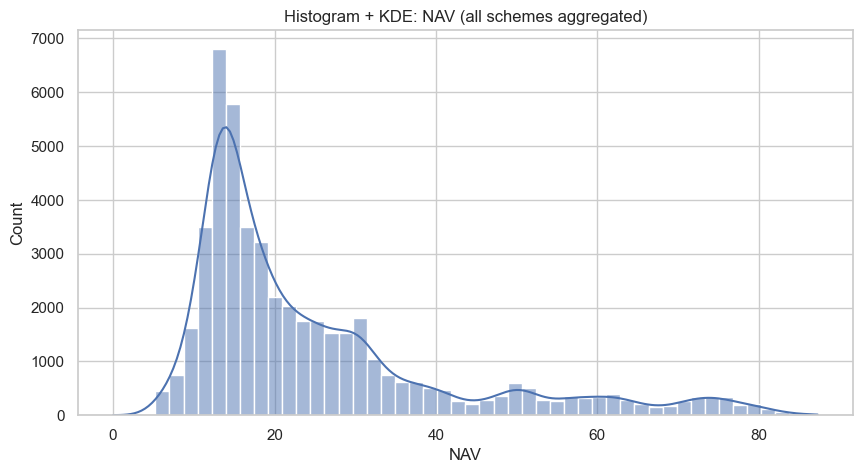

Plot: Daily returns histogram


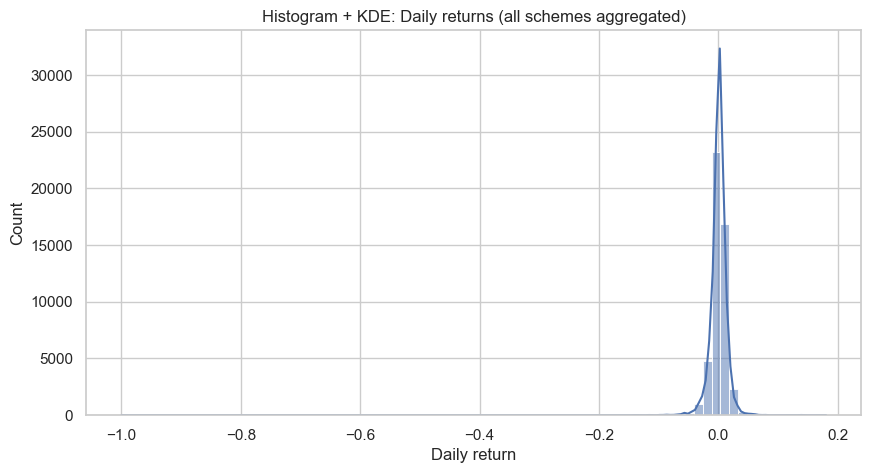

In [ ]:
# F) Aggregated univariate plots
print('Plot: NAV histogram')
plt.figure()
sns.histplot(nav, bins=NAV_BINS, kde=True)
plt.title('Histogram + KDE: NAV (all schemes aggregated)')
plt.xlabel('NAV')
plt.ylabel('Count')
plt.show()
plt.close()

print('Plot: Daily returns histogram')
plt.figure()
sns.histplot(daily_ret['daily_return'], bins=RET_BINS, kde=True)
plt.title('Histogram + KDE: Daily returns (all schemes aggregated)')
plt.xlabel('Daily return')
plt.ylabel('Count')
plt.show()
plt.close()


## G) Grouped / Per-scheme Univariate Plots (display inline)

Boxplots and violin plots for top schemes, counts per scheme, and counts per year to inspect scheme-level behaviour and data coverage.

Plot: NAV boxplot for top 6 schemes


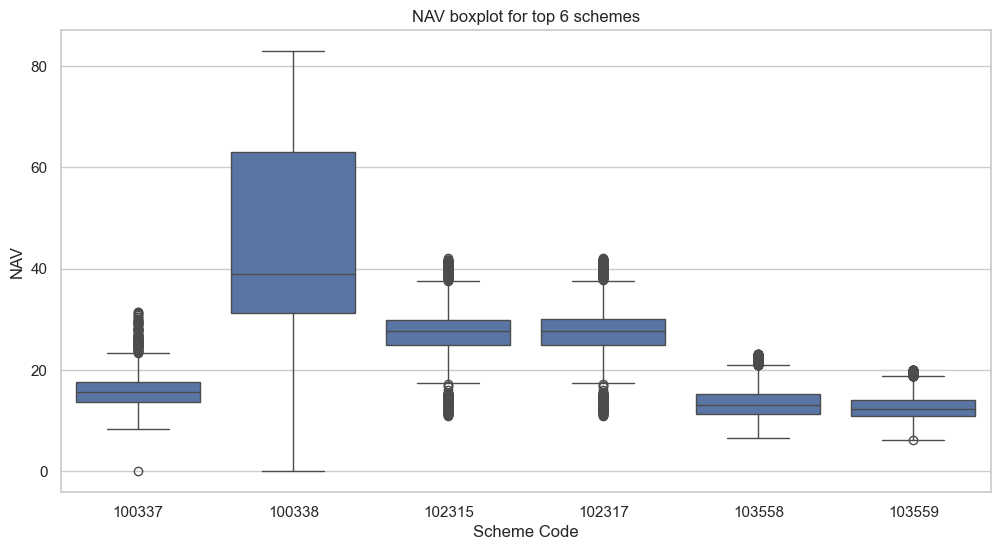

Plot: Violin plot of daily returns (top schemes)


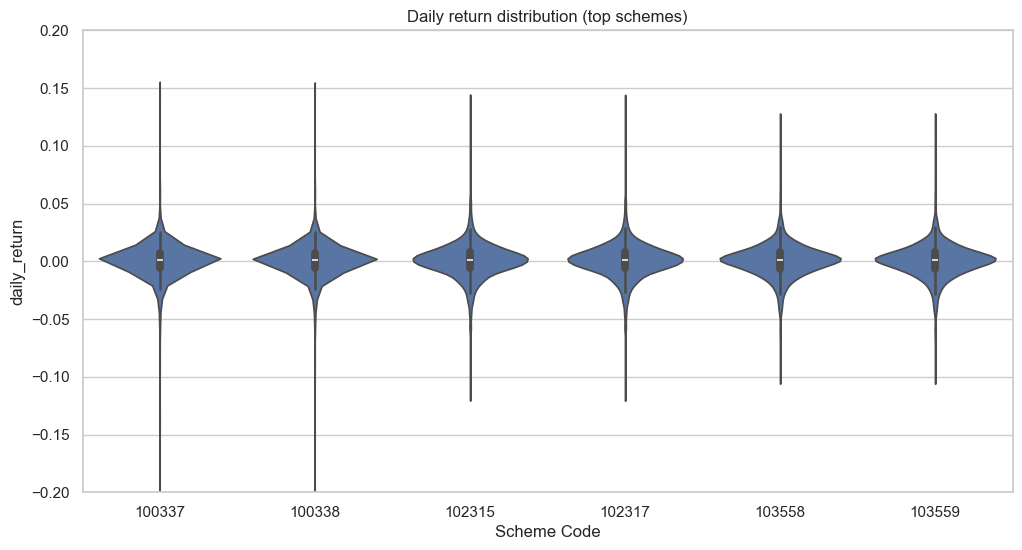

Plot: Count of top 10 schemes


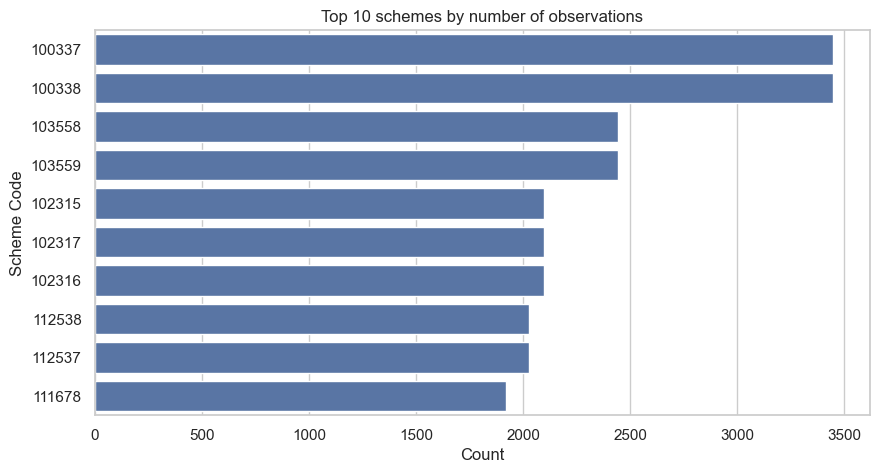

Plot: Observations per Year


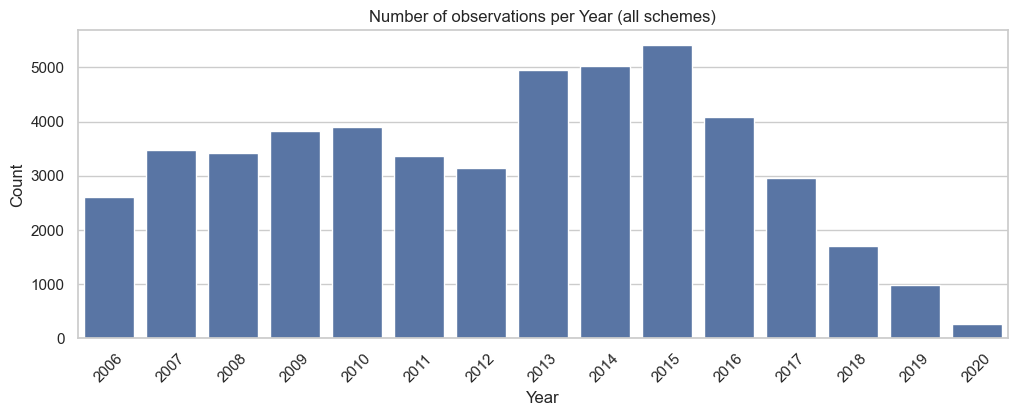

In [ ]:
# G) Grouped / per-scheme plots
top_schemes = df['Scheme Code'].value_counts().nlargest(TOP_N_SCHEMES).index.tolist()
print(f'Plot: NAV boxplot for top {len(top_schemes)} schemes')
plt.figure(figsize=(12,6))
sns.boxplot(x='Scheme Code', y='NAV', data=df[df['Scheme Code'].isin(top_schemes)])
plt.title(f'NAV boxplot for top {len(top_schemes)} schemes')
plt.show()
plt.close()

if not fast_mode:
    print('Plot: Violin plot of daily returns (top schemes)')
    plt.figure(figsize=(12,6))
    sns.violinplot(x='Scheme Code', y='daily_return', data=daily_ret[daily_ret['Scheme Code'].isin(top_schemes)])
    plt.title('Daily return distribution (top schemes)')
    plt.ylim(-0.2, 0.2)
    plt.show()
    plt.close()
else:
    print('fast_mode ON: skipping violin plot')

print('Plot: Count of top 10 schemes')
plt.figure(figsize=(10,5))
sns.countplot(y='Scheme Code', data=df, order=df['Scheme Code'].value_counts().nlargest(10).index)
plt.title('Top 10 schemes by number of observations')
plt.xlabel('Count')
plt.ylabel('Scheme Code')
plt.show()
plt.close()

print('Plot: Observations per Year')
df['Year'] = df['Date'].dt.year
plt.figure(figsize=(12,4))
sns.countplot(x='Year', data=df, order=sorted(df['Year'].unique()))
plt.title('Number of observations per Year (all schemes)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()
plt.close()


## H) IQR Outliers (display inline)

Identify NAV values outside the IQR fences (1.5 × IQR) and display a sample of the outliers inline for inspection. The full set of outliers is kept in memory for further analysis if required.

In [ ]:
# H) IQR outliers
Q1 = nav.quantile(0.25)
Q3 = nav.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_nav = df[(df['NAV'] < lower) | (df['NAV'] > upper)]
print(f'IQR fences: lower={lower:.6f}, upper={upper:.6f}')
print(f'Number of NAV outlier rows (IQR method): {len(outliers_nav):,}')

# display a sample to avoid flooding the notebook; show first 50 rows
display(outliers_nav.head(50))

# keep full DataFrame in memory
nav_outliers_df = outliers_nav.copy()


IQR fences: lower=-10.685000, upper=54.555000
Number of NAV outlier rows (IQR method): 4,327


,Scheme Code,Scheme Name,ISIN Div Payout/ISIN Growth,ISIN Div Reinvestment,NAV,Repurchase Price,Sale Price,Date,Year
5453,100338,SaharaTax Gain-Growth,INF515L01205,NaN,54.7310,54.1837,54.7310,2014-05-22,2014
5454,100338,SaharaTax Gain-Growth,INF515L01205,NaN,56.2347,55.6724,56.2347,2014-05-23,2014
5455,100338,SaharaTax Gain-Growth,INF515L01205,NaN,54.8376,54.2892,54.8376,2014-05-26,2014
5457,100338,SaharaTax Gain-Growth,INF515L01205,NaN,54.7797,54.2319,54.7797,2014-05-28,2014
5460,100338,SaharaTax Gain-Growth,INF515L01205,NaN,55.7893,55.2314,55.7893,2014-06-02,2014
5461,100338,SaharaTax Gain-Growth,INF515L01205,NaN,56.4345,55.8702,56.4345,2014-06-03,2014
5462,100338,SaharaTax Gain-Growth,INF515L01205,NaN,57.4800,56.9052,57.4800,2014-06-04,2014
5463,100338,SaharaTax Gain-Growth,INF515L01205,NaN,57.9223,57.3431,57.9223,2014-06-05,2014
5464,100338,SaharaTax Gain-Growth,INF515L01205,NaN,58.7197,58.1325,58.7197,2014-06-06,2014
5465,100338,SaharaTax Gain-Growth,INF515L01205,NaN,59.6625,59.0659,59.6625,2014-06-09,2014


## I) Per-scheme Helper (display inline)

A small routine to visualise a single scheme in more detail: NAV time series, NAV histogram, and daily returns histogram. Call `save_scheme_plots('<scheme_code>')` with a valid scheme code to run it.

In [ ]:
# I) Per-scheme helper
def save_scheme_plots(scheme_code, out_dir=None):
    s = df[df['Scheme Code'] == str(scheme_code)].sort_values('Date')
    if s.empty:
        print('No data for scheme', scheme_code)
        return
    print('NAV time series for scheme:', scheme_code)
    plt.figure(figsize=(10,4))
    plt.plot(s['Date'], s['NAV'])
    plt.title(f'NAV time series - Scheme {scheme_code}')
    plt.xlabel('Date')
    plt.ylabel('NAV')
    plt.show()
    plt.close()

    print('NAV histogram for scheme:', scheme_code)
    plt.figure()
    sns.histplot(s['NAV'].dropna(), bins=30, kde=True)
    plt.title(f'NAV histogram - Scheme {scheme_code}')
    plt.show()
    plt.close()

    ret = s['NAV'].pct_change().dropna()
    if len(ret) > 0:
        print('Daily returns histogram for scheme:', scheme_code)
        plt.figure()
        sns.histplot(ret, bins=40, kde=True)
        plt.title(f'Daily returns histogram - Scheme {scheme_code}')
        plt.show()
        plt.close()

    print('Finished visualising', scheme_code)

